# Regime-Switching SSMs with `RSSSM` (K = 2)

Cognitive states are rarely static. Over a session a participant may drift between an **attentive** and a **distracted** state, or switch between a **speed-emphasis** and an **accuracy-emphasis** strategy. A *regime-switching sequential sampling model* captures this directly: a latent Markov chain moves the participant between a small number of **regimes** across trials, and within each regime behaviour follows a standard SSM (here a drift-diffusion model) whose parameters take regime-specific values.

The low-level tutorial [*Joint Modeling of Latent Cognitive States and Decision Processes*](hmm_ddm_regime_switching.ipynb) builds this model **by hand** in PyMC. This tutorial **reproduces everything in that tutorial using `hssm.RSSSM`** — the high-level class that packages the forward algorithm, the label-switching constraint, the two emission backends, and the regime-recovery routine — and then goes further, adding LOO model comparison and **regime-specific lapse rates**, which the class makes trivial.

**The model.** With $K = 2$ regimes for one participant:

- **Latent regimes:** $s_t \mid s_{t-1} \sim \text{Categorical}(P_{s_{t-1},\,\cdot})$, with $P$ the $2\times2$ transition matrix and $s_1 \sim \pi_0$.
- **Emissions:** $(rt_t, \text{resp}_t) \mid s_t = k \sim \text{DDM}(v_k, a, z, t)$ — the drift $v$ *switches*, while $a, z, t$ are *shared*.
- **Inference:** the discrete regimes are marginalised by the forward algorithm, leaving a continuous model for NUTS; the regimes are recovered afterwards.

## Part 1: Setup
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

import hssm

np.random.seed(0)

## Part 2: Simulate regime-switching data
---

500 trials from two regimes that differ only in drift rate — regime 0 *distracted* ($v=0.2$), regime 1 *attentive* ($v=1.5$) — with shared $a=0.8$, $z=0.5$, $t=0.3$ and a **sticky** transition matrix (switches are rare).

In [2]:
def simulate_regime_switching_ddm(n_trials, v_per_regime, a, z, t, P, pi0, seed=0):
    """Simulate (rt, response) from a regime-switching DDM."""
    rng = np.random.default_rng(seed)
    K = len(v_per_regime)
    regimes = np.empty(n_trials, dtype=int)
    regimes[0] = rng.choice(K, p=pi0)
    for i in range(1, n_trials):
        regimes[i] = rng.choice(K, p=P[regimes[i - 1]])
    data = np.empty((n_trials, 2))
    for k in range(K):
        m = regimes == k
        n_k = int(m.sum())
        if n_k:
            data[m] = hssm.simulate_data(
                model="ddm", theta={"v": v_per_regime[k], "a": a, "z": z, "t": t},
                size=n_k, random_state=seed + k, output_df=False,
            )
    return pd.DataFrame(data, columns=["rt", "response"]), regimes


N_TRIALS = 500
V_TRUE, A_TRUE, Z_TRUE, T_TRUE = [0.2, 1.5], 0.8, 0.5, 0.3
P_TRUE = np.array([[0.95, 0.05], [0.10, 0.90]])
PI0_TRUE = np.array([0.8, 0.2])
df, true_regimes = simulate_regime_switching_ddm(
    N_TRIALS, V_TRUE, A_TRUE, Z_TRUE, T_TRUE, P_TRUE, PI0_TRUE, seed=1
)
df.head()

,rt,response
0,0.618584,-1.0
1,0.756348,1.0
2,0.605561,1.0
3,2.095907,1.0
4,1.193549,1.0


The latent structure is visible directly: the top panel shows the ground-truth regime bands, the bottom the **signed RT** ($\text{rt}\times\text{response}$) coloured by regime — the attentive regime is faster and more consistently positive.

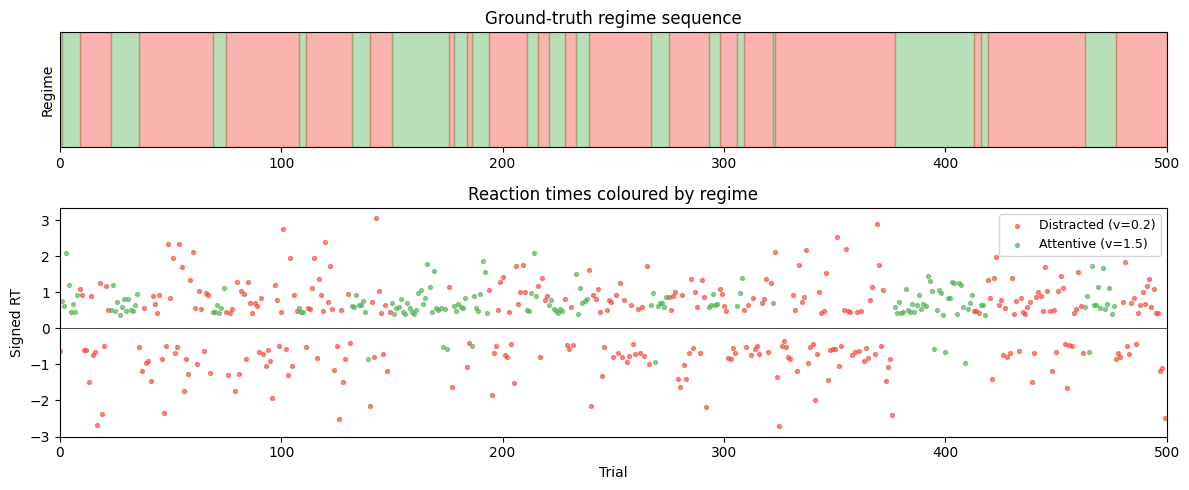

In [3]:
colors = {0: "#F44336", 1: "#4CAF50"}
labels = {0: "Distracted (v=0.2)", 1: "Attentive (v=1.5)"}
fig, axes = plt.subplots(2, 1, figsize=(12, 5), gridspec_kw={"height_ratios": [1, 2]})
trials = np.arange(N_TRIALS)
ax = axes[0]; start = 0
for i in range(1, N_TRIALS + 1):
    if i == N_TRIALS or true_regimes[i] != true_regimes[start]:
        ax.axvspan(start, i, alpha=0.4, color=colors[true_regimes[start]]); start = i
ax.set_xlim(0, N_TRIALS); ax.set_yticks([]); ax.set_ylabel("Regime")
ax.set_title("Ground-truth regime sequence")
ax = axes[1]
for k in (0, 1):
    m = true_regimes == k
    ax.scatter(trials[m], df["rt"].values[m] * df["response"].values[m],
               s=8, alpha=0.6, color=colors[k], label=labels[k])
ax.axhline(0, color="k", lw=0.5); ax.set_xlim(0, N_TRIALS)
ax.set_xlabel("Trial"); ax.set_ylabel("Signed RT"); ax.legend(loc="upper right", fontsize=9)
ax.set_title("Reaction times coloured by regime"); fig.tight_layout(); plt.show()

## Part 3: Build the analytical model
---

The whole model is one call. `switching_params=["v"]` makes the drift a per-regime vector; everything else is shared. `RSSSM` marginalises the regimes with the forward algorithm and adds an **`ordered` transform** to the anchor `v`, so $v_0 < v_1$ — this breaks the label-switching symmetry (the likelihood is invariant to relabelling regimes). By convention **regime 0 is the low-drift regime**.

No participant column found; treating all rows as a single participant.


RSSSM model initialized successfully.


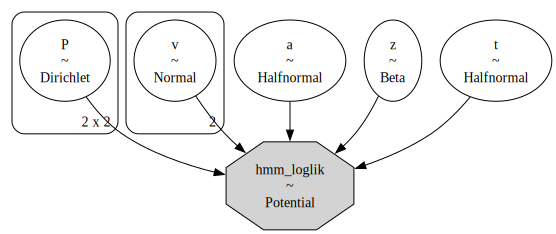

In [4]:
model = hssm.RSSSM(
    data=df, model="ddm", K=2, switching_params=["v"],
    v={"name": "Normal", "mu": 0.0, "sigma": 3.0},
    a={"name": "HalfNormal", "sigma": 2.0},
    z={"name": "Beta", "alpha": 10, "beta": 10},
    t={"name": "HalfNormal", "sigma": 0.5},
)
model.graph()

**How the likelihood works.** For every trial $t$ and regime $k$, `RSSSM` evaluates $\log p(rt_t, \text{resp}_t \mid \theta_k)$, then runs a log-space **forward recursion** tracking $\log\alpha_t(k)=\log p(y_{1:t}, s_t=k)$ — combining the previous beliefs with the transition matrix $P$ and the current emission. Summing over regimes at the last trial gives $\log p(y_{1:T})$, contributed as a single `pm.Potential`, so NUTS only sees continuous parameters. (The recursion is normalised internally for numerical stability on long sessions.)

## Part 4: Fit and check
---
`RSSSM.sample()` defaults to the `numpyro` NUTS sampler (the forward `scan` JIT-compiles to `jax.lax.scan`).

In [5]:
idata = model.sample(draws=1000, tune=1000, chains=2, target_accept=0.9, random_seed=42)

/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/jax/_src/interpreters/mlir.py:1178: UserWarning: Some donated buffers were not usable: ShapedArray(float64[2,1000,2,1]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [6]:
model.summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
t,0.305,0.008,0.288,0.320,0.000,0.000,1204.0,1236.0,1.0
a,0.824,0.021,0.787,0.865,0.001,0.000,1008.0,1130.0,1.0
z,0.508,0.017,0.476,0.539,0.000,0.000,1448.0,1483.0,1.0
v[0],0.063,0.153,-0.206,0.351,0.005,0.004,1027.0,905.0,1.0
v[1],1.737,0.416,1.049,2.541,0.014,0.011,941.0,1050.0,1.0
"P[0, 0]",0.917,0.034,0.851,0.972,0.001,0.001,1117.0,1075.0,1.0
"P[0, 1]",0.083,0.034,0.028,0.149,0.001,0.001,1117.0,1075.0,1.0
"P[1, 0]",0.143,0.042,0.068,0.221,0.001,0.001,1121.0,1380.0,1.0
"P[1, 1]",0.857,0.042,0.779,0.932,0.001,0.001,1121.0,1380.0,1.0


Posterior means vs. the ground truth:

In [7]:
def recovery_table(idata, v_true=V_TRUE):
    post = idata.posterior
    rows = [("v[0]", float(post["v"].mean(("chain","draw"))[0]), v_true[0]),
            ("v[1]", float(post["v"].mean(("chain","draw"))[1]), v_true[1]),
            ("a", float(post["a"].mean()), A_TRUE),
            ("z", float(post["z"].mean()), Z_TRUE),
            ("t", float(post["t"].mean()), T_TRUE)]
    return pd.DataFrame([(n, f"{e:.3f}", v) for n, e, v in rows],
                        columns=["parameter", "posterior mean", "true value"])
recovery_table(idata)

,parameter,posterior mean,true value
0,v[0],0.063,0.2
1,v[1],1.737,1.5
2,a,0.824,0.8
3,z,0.508,0.5
4,t,0.305,0.3


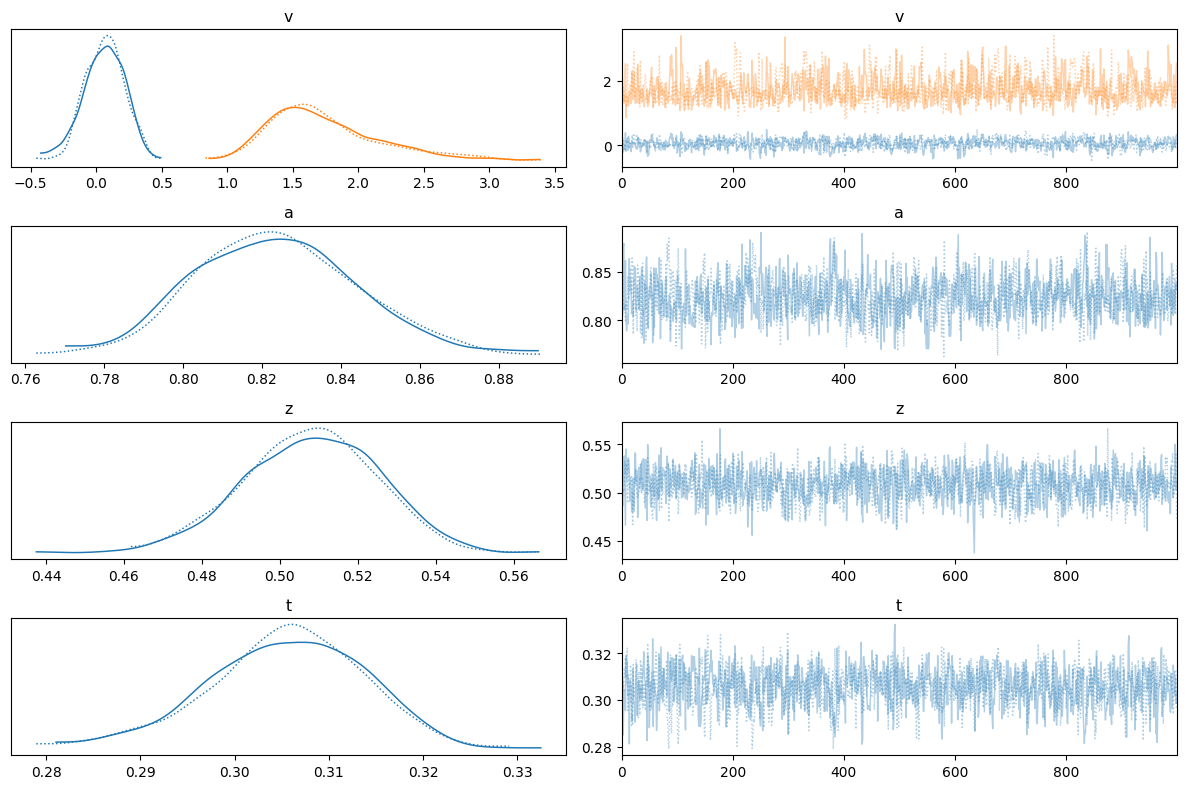

In [8]:
az.plot_trace(idata, var_names=["v", "a", "z", "t"], compact=True); plt.tight_layout()

A pair plot reveals the posterior geometry and parameter trade-offs:

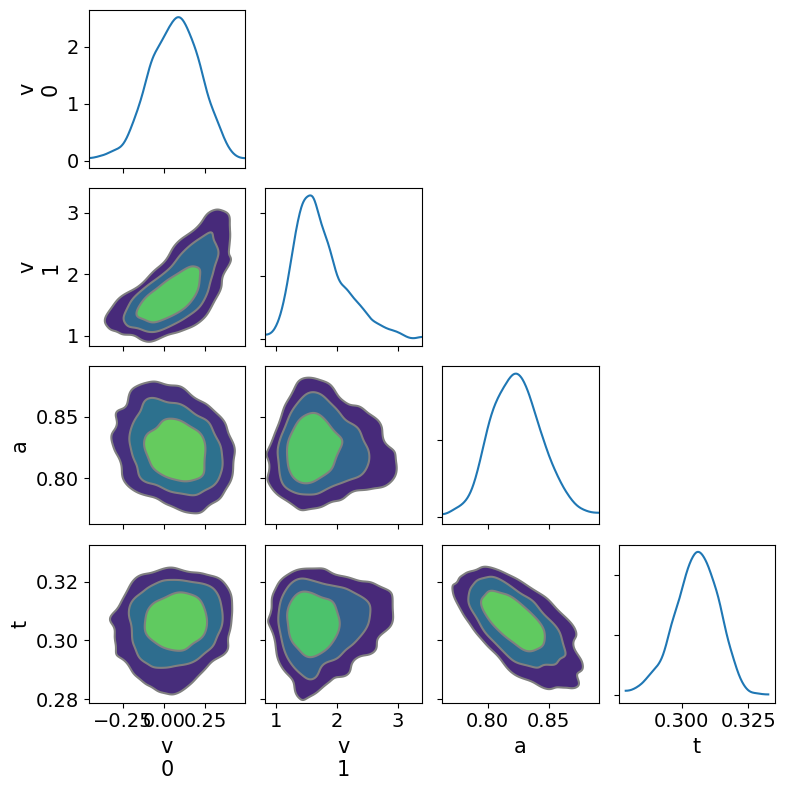

In [9]:
az.plot_pair(idata, var_names=["v", "a", "t"], kind="kde", marginals=True, figsize=(8, 8)); plt.tight_layout()

## Part 5: Recover the latent regimes (FFBS)
---
NUTS marginalised the regimes out, so we recover them *post-hoc* with **Forward-Filter Backward-Sample** via `infer_regimes()`. The forward filter gives $\alpha_t(k)=p(y_{1:t},s_t=k)$ (past data only); picking $\arg\max_k\alpha_t(k)$ per trial would ignore the Markov structure. The backward pass samples in reverse, $s_t \sim p(s_t=k\mid s_{t+1}, y_{1:T}) \propto \alpha_t(k)\,P_{k,s_{t+1}}$, giving sequences jointly consistent with the data **and** the dynamics. Repeating across posterior draws propagates parameter uncertainty.

In [10]:
regimes_idata = model.infer_regimes(idata, n_draws=200, seed=0)

Per-trial regime recovery accuracy (analytical): 85.8%


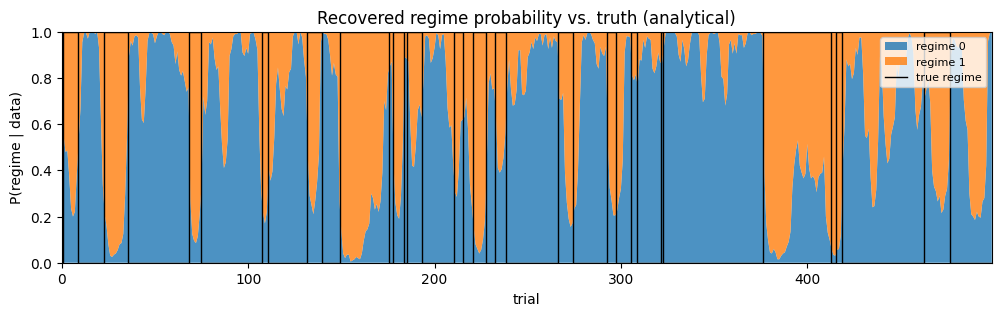

In [11]:
def recovery_plot(model, regimes_idata, title):
    ax = model.plot_regime_recovery(regimes_idata, true_regimes=true_regimes)
    ax.set_title(title); return ax

recovery_plot(model, regimes_idata, "Recovered regime probability vs. truth (analytical)")
freq = regimes_idata.posterior_regimes["regime_sample_frequency"].values[0]
acc = (freq.argmax(1) == true_regimes).mean()
print(f"Per-trial regime recovery accuracy (analytical): {acc:.1%}")

## Part 6: Swap the emission backend — LAN (approx. differentiable)
---
The hand-built tutorial showed the *same* HMM scaffold with two DDM likelihoods: the **analytical** density (Navarro & Fuss) and an **approximate differentiable** LAN (a neural network served via ONNX). With `RSSSM` switching backend is a **single keyword** — `loglik_kind="approx_differentiable"` — and is the only way to fit SSMs that have *no* analytical likelihood at all (`angle`, `levy`, …). Everything downstream (sampling, FFBS, LOO) is identical.

In [12]:
model_lan = hssm.RSSSM(
    data=df, model="ddm", K=2, switching_params=["v"],
    loglik_kind="approx_differentiable", backend="jax",
    v={"name": "Normal", "mu": 0.0, "sigma": 3.0},
    a={"name": "HalfNormal", "sigma": 2.0},
    z={"name": "Beta", "alpha": 10, "beta": 10},
    t={"name": "HalfNormal", "sigma": 0.5},
)
idata_lan = model_lan.sample(draws=1000, tune=1000, chains=2, target_accept=0.9, random_seed=42)
recovery_table(idata_lan)

No participant column found; treating all rows as a single participant.


RSSSM model initialized successfully.


/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(



/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/jax/_src/interpreters/mlir.py:1178: UserWarning: Some donated buffers were not usable: ShapedArray(float64[2,1000,2,1]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


We recommend running at least 4 chains for robust computation of convergence diagnostics


,parameter,posterior mean,true value
0,v[0],0.122,0.2
1,v[1],1.852,1.5
2,a,0.803,0.8
3,z,0.507,0.5
4,t,0.309,0.3


Per-trial regime recovery accuracy (LAN): 82.4%


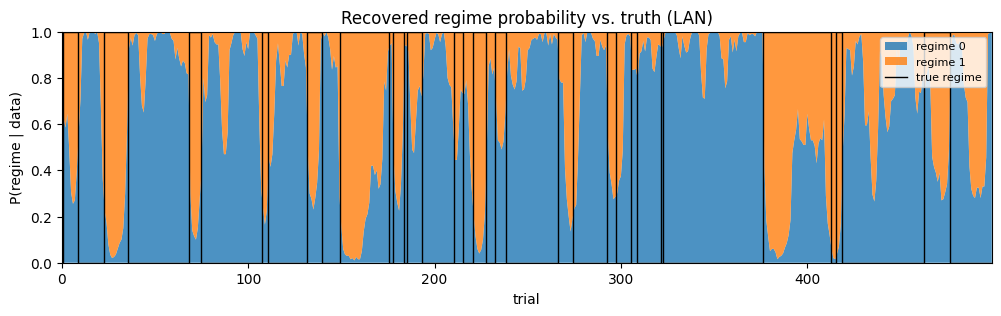

In [13]:
regimes_lan = model_lan.infer_regimes(idata_lan, n_draws=200, seed=0)
recovery_plot(model_lan, regimes_lan, "Recovered regime probability vs. truth (LAN)")
freq_lan = regimes_lan.posterior_regimes["regime_sample_frequency"].values[0]
print(f"Per-trial regime recovery accuracy (LAN): {(freq_lan.argmax(1) == true_regimes).mean():.1%}")

## Part 7: Compare the analytical and LAN posteriors
---
The two backends should agree closely. We overlay their posterior densities, compare transition-matrix recovery against the truth, and check the RT distributions per recovered regime.

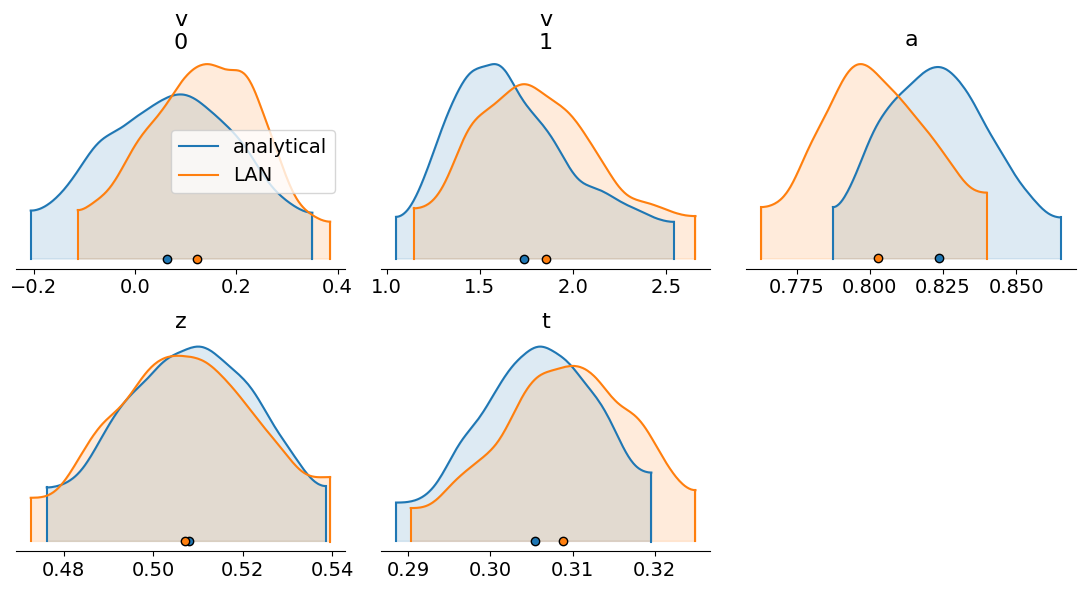

In [14]:
az.plot_density([idata, idata_lan], data_labels=["analytical", "LAN"],
                var_names=["v", "a", "z", "t"], shade=0.15, figsize=(11, 6)); plt.tight_layout()

**Transition-matrix recovery.** The posterior of each entry of $P$ against its true value (dashed):

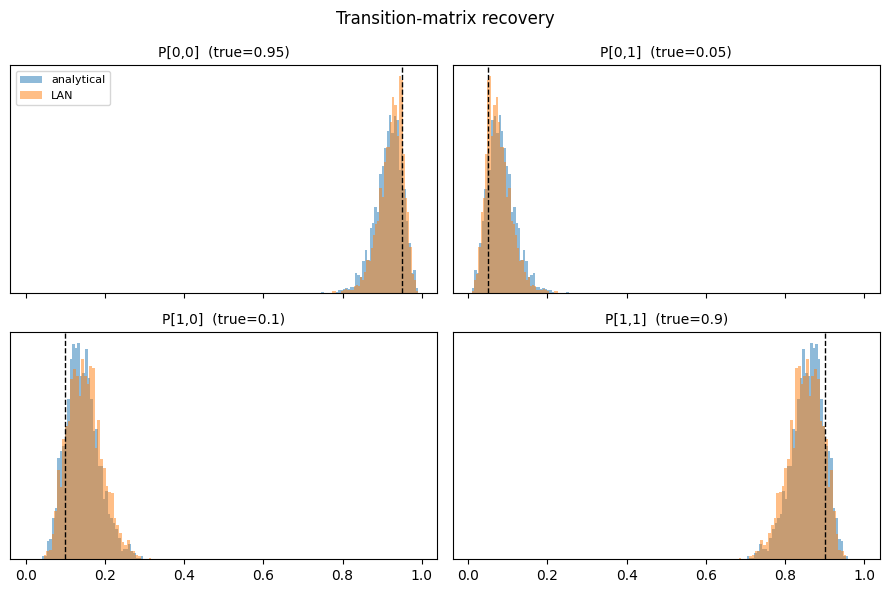

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        for lab, idt, c in [("analytical", idata, "C0"), ("LAN", idata_lan, "C1")]:
            samples = idt.posterior["P"].values[..., i, j].ravel()
            ax.hist(samples, bins=40, density=True, alpha=0.5, color=c, label=lab)
        ax.axvline(P_TRUE[i, j], color="k", ls="--", lw=1)
        ax.set_title(f"P[{i},{j}]  (true={P_TRUE[i, j]})", fontsize=10)
        ax.set_yticks([])
axes[0, 0].legend(fontsize=8); fig.suptitle("Transition-matrix recovery"); fig.tight_layout()

**RT by recovered regime.** Splitting observed RTs by the regime FFBS assigns confirms the two regimes are behaviourally distinct:

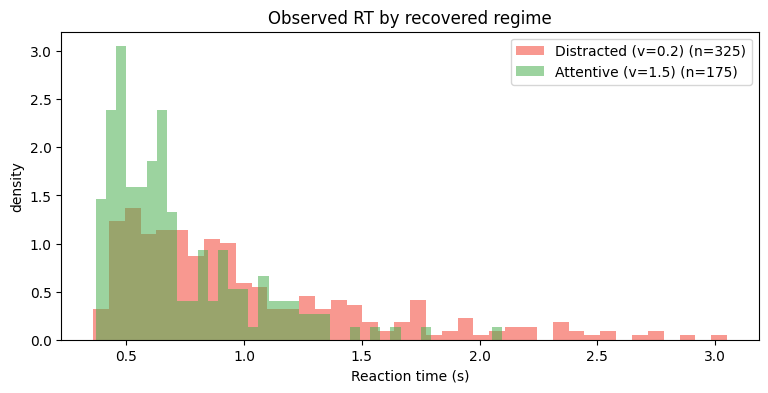

In [16]:
map_regime = freq.argmax(1)
fig, ax = plt.subplots(figsize=(9, 4))
for k in (0, 1):
    rt_k = df["rt"].values[map_regime == k]
    ax.hist(rt_k, bins=40, alpha=0.55, color=colors[k], density=True,
            label=f"{labels[k]} (n={len(rt_k)})")
ax.set_xlabel("Reaction time (s)"); ax.set_ylabel("density")
ax.legend(); ax.set_title("Observed RT by recovered regime"); plt.show()

## Part 8: Model comparison with LOO
---
*New with the class.* Because the sampler contributes only a scalar marginal, the per-trial `log_likelihood` group that `arviz.loo`/`waic` need is reconstructed *post-hoc* (`compute_log_likelihood`, or `sample(..., include_log_likelihood=True)`). Here the two backends fit the *same* model, so their LOO scores should be statistically indistinguishable — a useful consistency check; in the companion K=3 tutorial we use LOO to actually **choose the number of regimes**.

In [17]:
model.compute_log_likelihood(idata)
model_lan.compute_log_likelihood(idata_lan)
az.compare({"analytical": idata, "LAN": idata_lan})

Reconstructing per-trial log-likelihood over 2000 draws (2 chains x 1000) for 1 participants; this can be slow on large posteriors.


Reconstructing per-trial log-likelihood over 2000 draws (2 chains x 1000) for 1 participants; this can be slow on large posteriors.


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
LAN,0,-471.614537,7.255970,0.000000,1.0,24.178016,0.000000,False,log
analytical,1,-473.883915,7.987403,2.269378,0.0,24.233530,0.964112,False,log


## Part 9: Beyond the original — regime-specific lapses
---
*New with the class.* Real data contains **lapses** — fast guesses or attention failures that the DDM cannot explain. Often the *rate* of lapsing is itself regime-dependent (a distracted regime lapses more). `RSSSM` supports a per-regime lapse by adding `p_outlier` to `switching_params`: regime $k$'s emission becomes the mixture $(1-p_k)\,\text{DDM}(\theta_k) + p_k\,\text{lapse}$, with a uniform lapse over RT. We inject a 30% lapse rate into the distracted regime and 3% into the attentive one, then recover both.

In [18]:
data2, reg2 = simulate_regime_switching_ddm(500, V_TRUE, A_TRUE, Z_TRUE, T_TRUE,
                                            P_TRUE, PI0_TRUE, seed=5)
rng = np.random.default_rng(7); true_lapse = {0: 0.30, 1: 0.03}
for i in range(len(data2)):
    if rng.random() < true_lapse[reg2[i]]:
        data2.iloc[i, 0] = rng.uniform(0.0, 20.0)        # lapse RT ~ Uniform(0, 20)
        data2.iloc[i, 1] = rng.choice([-1.0, 1.0])       # random choice
model_lapse = hssm.RSSSM(
    data=data2, model="ddm", K=2, switching_params=["v", "p_outlier"],
    v={"name": "Normal", "mu": 0.0, "sigma": 3.0},
    p_outlier={"name": "Beta", "alpha": 1, "beta": 8},
)
idata_lapse = model_lapse.sample(draws=1000, tune=1000, chains=2, target_accept=0.9, random_seed=1)
p = idata_lapse.posterior["p_outlier"].mean(("chain", "draw")).values
pd.DataFrame({"regime": ["0 (distracted)", "1 (attentive)"],
             "recovered p_outlier": np.round(p, 3), "true p_outlier": [0.30, 0.03]})

No participant column found; treating all rows as a single participant.


RSSSM model initialized successfully.


/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/jax/_src/interpreters/mlir.py:1178: UserWarning: Some donated buffers were not usable: ShapedArray(float64[2,1000,2,1]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
We recommend running at least 4 chains for robust computation of convergence diagnostics


,regime,recovered p_outlier,true p_outlier
0,0 (distracted),0.422,0.30
1,1 (attentive),0.044,0.03


The distinct per-regime lapse rates are recovered. Without modelling them, those lapse trials would bias the drift estimates.

## Part 10: Summary and extensions
---
### What we did
- Reproduced the entire hand-built HMM-DDM tutorial in a handful of `RSSSM` calls: simulation, the forward-algorithm likelihood, NUTS fitting, FFBS regime recovery, **both** the analytical and LAN emission backends, and the analytical-vs-LAN / transition-matrix / RT-by-regime comparisons.
- Added LOO model comparison and **per-regime lapse rates** — both essentially free with the class.

### Interpretation tips
- **Label switching.** The `ordered` transform makes permuted-label modes unreachable; chains should be unimodal. Disabling it (`ordering="none"`) reintroduces multi-modality.
- **Sticky prior.** The default transition prior favours self-transitions — a sensible bias for cognitive data; tune it with `transition_prior`.
- **Backends.** Analytical and LAN agree here; LAN is required for SSMs lacking an analytical density.

### Where to go next
- **More regimes:** the companion tutorial [*Regime-switching SSMs at K = 3*](rsssm_k3.ipynb) handles three regimes and uses LOO to choose $K$.
- **More switching parameters:** `switching_params=["v", "a"]`.
- **Any SSM:** swap `model="ddm"` for `"angle"`, `"levy"`, … — analytical or LAN, the workflow is unchanged.